# PhysioMTL

Zhu, J., Darnell, G., Kumar, A., Zhao, D., Li, B., Nguyen, X., & Ren, S.Y. (2022). PhysioMTL: Personalizing physiological patterns using optimal transport multi-task regression. Proceedings of the Conference on Health, Inference, and Learning, Proceedings of Machine Learning Research, 174, 354-374. Available from https://proceedings.mlr.press/v174/zhu22a.html.

# Requirements & Imports

This code is intended to be run on `Python 3.9`.

Multi-task regression library MuTaR is utilized to compare PhysioMTL evaluation with various other methods like the original paper, including the following:

- Group Lasso
- Multi-Level Lasso
- Dirty Model
- MT Wasserstein
- Reweighted MT Wasserstein
- PhysioMTL

Ecternal libraries are required to run the code, including:

* Numpy (2.2.5)
* Pandas (2.3.3)
* Matplotlib (3.10.1)
* Pot (0.9.5)
* Scipy (1.15.2)

In [8]:

!git clone https://github.com/hichamjanati/mutar
!pip install cython
!pip install -e ./mutar

%pip install numpy pandas psutil matplotlib scipy scikit-learn POT

import site 
site.main()

fatal: destination path 'mutar' already exists and is not an empty directory.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Obtaining file:///C:/Users/zayaa/workspaces/physioMTL/mutar
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Attempting uninstall: mutar
    Found existing installation: mutar 0.0.1
    Uninstalling mutar-0.0.1:
      Successfully uninstalled mutar-0.0.1
  Running setup.py develop for mutar
  Rolling back uninstall of mutar
  Moving to c:\users\zayaa\workspaces\physiomtl\venv\lib\site-packages\mutar.egg-link
   from C:\Users\zayaa\AppData\Local\Temp\pip-uninstall-3gjf9esr\mutar.egg-link


  DEPRECATION: Legacy editable install of mutar==0.0.1 from file:///C:/Users/zayaa/workspaces/physioMTL/mutar (setup.py develop) is deprecated. pip 25.0 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457
    error: subprocess-exited-with-error
    
    × python setup.py develop did not run successfully.
    │ exit code: 1
    ╰─> [62 lines of output]
        C:\Users\zayaa\workspaces\physioMTL\venv\lib\site-packages\setuptools\dist.py:452: SetuptoolsDeprecationWarning: Invalid dash-separated options
        !!
        
                ********************************************************************************
                Usage of dash-separated 'descripti

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import platform
import psutil
import time

# Regression methods
import zipfile
import numpy as np
import pandas as pd
import matplotlib.cm as cm
import random
from mutar import GroupLasso, DirtyModel, MTW, MultiLevelLasso, ReMTW
from scipy import stats
from matplotlib import pyplot as plt

## Identify System Resources

These method definitions are used in various downstream classes to calculate precise computational requirements of both PhysioMTL and comparable methods. System information is printed and should be evaluated when comparing your results with results reported in our paper, as varation in CPU/memory and runtime can introduce considerable differences in CPU utilization. System requirements used in the creation of the paper are as follows:

* Architecture: x86_64
* RAM: 13GB
* CPU Cores (Physical): 1
* CPU Cores (Logical): 2
* Platform: Linux



In [10]:
def get_size(bytes):
    bucket = 1024
    for unit in ["", "K", "M", "G", "T", "P"]:
        if bytes < bucket:
            return f"{bytes:.2f}{unit}B"
        bytes /= bucket

def get_memory_utilization():
    svmem = psutil.virtual_memory()
    return {
        'Memory (Total)': f'{get_size(svmem.total)}',
        'Memory (Available)': f'{get_size(svmem.available)}',
        'Memory (Used)': f'{get_size(svmem.used)}',
        'Memory Utilization': f'{svmem.percent}%'
    }

def get_system_info():
    svmem = psutil.virtual_memory()
    return {
        'Platform': platform.system(),
        'Architecture': platform.machine(),
        'Processor': platform.processor(),
        'RAM': f'{round(psutil.virtual_memory().total / (1024 ** 3), 3)} GB',
        'CPU Cores (Physical)': psutil.cpu_count(logical=False),
        'CPU Cores (Total)': psutil.cpu_count(logical=True)
    } | get_memory_utilization()

def get_cpu_seconds(cycles):
    return cycles / psutil.cpu_count(logical=True) / 1000000000

print(get_system_info())

{'Platform': 'Windows', 'Architecture': 'AMD64', 'Processor': 'AMD64 Family 25 Model 33 Stepping 0, AuthenticAMD', 'RAM': '31.928 GB', 'CPU Cores (Physical)': 8, 'CPU Cores (Total)': 16, 'Memory (Total)': '31.93GB', 'Memory (Available)': '15.81GB', 'Memory (Used)': '16.12GB', 'Memory Utilization': '50.5%'}


# MMASH Data Set

The MMASH dataset contains 24-hour psycho-physiological data from 22 healthy adults. It includes data on respiratory rate, sleep quality, physical activity, anxiety, stress, and emotions Multilevel Monitoring of Activity and Sleep in Healthy People (MMASH) [3]

##Download MMASH

In [11]:
!mkdir data
!mkdir data/figures

with zipfile.ZipFile('mmash/mmash.zip', 'r') as zip_ref:
  zip_ref.extractall('mmash')


A subdirectory or file data already exists.


The syntax of the command is incorrect.


##Preprocess MMASH

Preprocessing of the MMASH dataset is by converting respiratory rate to HRV in 5 minute intervals, omission of instances with a z-score over a threshold (2.5 by default). We also perform additional data cleansing to match behavior followed by the authors of the original paper, which included ignoring patient 4 (due to extreme HRV measurements) and populating missing sleep and age data on two other patients.

In [18]:
# Scripting constants
BASELINE_DATES = {1: "2020-08-01", 2: "2020-08-02"}
RANDOM_STATE = 12345
USER_FILE_PREFIX = "./mmash/DataPaper/user_"
TASKS = range(1, 23)

# Data set variables
RELEVANT_ACTIVITY = [4, 5]
USER_INFO_FIELDS = ["Age", "Height", "Weight"]
OMIT_TASKS = [4,]
OVERWRITES = {3: [5,60], 11: [4,6.5], 18: [0,22]}
RAD_HOUR = 2.0 * np.pi / 24

# Pre-processing hyperparameters
IBIS_UPPER = 2.1
IBIS_LOWER = 0.3
FREQUENCY = "5min"
NOISE_UPPER = 55.0
NOISE_SAMPLE_PERCENT = 0.85

In [19]:
class MMASH:
    def __init__(self, tasks, max_zscore, max_noise=NOISE_UPPER):
        self.max_zscore = max_zscore
        if self.max_zscore is None:
            self.max_zscore = 999999
        self.max_noise = max_noise
        self.X, self.S, self.Y = [], [], []
        self.start_processing_cycles = time.perf_counter()

        for i in tasks:
            i_start = time.perf_counter()
            user_folder = USER_FILE_PREFIX + str(i)

            sleep_value = self.get_sleep_data(pd.read_csv(user_folder + "/sleep.csv"))
            activity_value = self.get_activity_data(pd.read_csv(user_folder + "/Activity.csv", header=0))
            user_info_value = self.get_user_info_data(pd.read_csv(user_folder + "/user_info.csv", header=0))
            questionnaire_value = self.get_questionnaire_data(pd.read_csv(user_folder + "/questionnaire.csv", header=0))
            rr_value = self.get_rr_data(pd.read_csv(user_folder + "/RR.csv", header=0))

            t_hour = rr_value["t_hour"].values
            s_vector = np.hstack([user_info_value, activity_value, sleep_value, questionnaire_value])
            if i in OVERWRITES:
                s_vector[OVERWRITES[i][0]] = OVERWRITES[i][1]

            X_i = np.asarray([np.sin(RAD_HOUR * t_hour), np.cos(RAD_HOUR * t_hour), np.ones(t_hour.shape[0], )]).T
            Y_i = rr_value["value"].values.reshape((-1, 1))

            print(f"Task {i}: X_i shape: {X_i.shape}, Y_i shape: {Y_i.shape}, S_vector shape: {s_vector.shape}")

            self.X.append(X_i)
            self.S.append(s_vector.reshape(-1, 1))
            self.Y.append(Y_i)

            i_cycles = time.perf_counter() - i_start
            print(f'{i}: preprocessed task, y-mean = {rr_value["value"].mean()}, elapsed time: {i_cycles} seconds')

        self.X = np.asarray(self.X, dtype=object)
        self.S = np.asarray(self.S)
        self.Y = np.asarray(self.Y, dtype=object)
        self.elapsed_processing_cycles = time.perf_counter() - self.start_processing_cycles
        print(f'finished processing mmash data set, elapsed cycles: {self.elapsed_processing_cycles} seconds')

    def get_sleep_data(self, data):
        return data["Total Minutes in Bed"].sum() / 60

    def get_activity_data(self, data):
        data = data.copy().dropna()
        activity = lambda x: pd.to_timedelta(x["End"] + ":00") - pd.to_timedelta(x["Start"] + ":00")
        data["time_start_pd"] = data.apply(activity, axis=1)
        data["time_end_pd"] = data.apply(activity, axis=1)
        data["time_last_hour"] = data["time_end_pd"].apply(lambda x: x.seconds / 3600)
        data = data.loc[data["Activity"].isin(RELEVANT_ACTIVITY)]
        return data["time_last_hour"].sum() if not data.empty else 0

    def get_user_info_data(self, data):
        data = data[USER_INFO_FIELDS].loc[0].values
        return [data[0], data[1] / 100.0, data[2]]

    def get_questionnaire_data(self, data):
        return data["Daily_stress"].loc[0]

    def get_rr_data(self, data):
        data["new_time"] = data.apply(lambda ds: pd.to_datetime(BASELINE_DATES.get(ds["day"], BASELINE_DATES[2]) + " " + str(ds["time"])), axis=1)
        data['ibi_s'] = [x if x < IBIS_UPPER and x > IBIS_LOWER else np.nan for x in data['ibi_s']]
        data = [w for _, w in data.dropna().groupby(pd.Grouper(key='new_time', freq=FREQUENCY)) if not w.empty]
        rr_value = pd.DataFrame({
            "new_time": [x["new_time"].mean() for x in data],
            "value": [np.std(1000 * x["ibi_s"], ddof=1) for x in data]
        })
        no_noise = rr_value["value"] < self.max_noise
        no_noise = rr_value[no_noise].sample(int(NOISE_SAMPLE_PERCENT * no_noise.sum()), random_state=RANDOM_STATE)
        rr_value = rr_value.drop(no_noise.index)
        rr_value = rr_value.loc[np.abs(stats.zscore(rr_value["value"])) < self.max_zscore]
        rr_value = rr_value.loc[rr_value["value"] > 12]
        rr_value["t_hour"] = rr_value["new_time"].apply(lambda x: (x - pd.Timestamp(BASELINE_DATES[1] + " 00:00:00")).total_seconds() / 3600)
        return rr_value

In [20]:
tasks = [i for i in TASKS if i not in OMIT_TASKS]
mmash = MMASH(tasks, max_zscore=2.5)

Task 1: X_i shape: (226, 3), Y_i shape: (226, 1), S_vector shape: (6,)
1: preprocessed task, y-mean = 85.56476822678721, elapsed time: 25.264260800000102 seconds
Task 2: X_i shape: (204, 3), Y_i shape: (204, 1), S_vector shape: (6,)
2: preprocessed task, y-mean = 100.33561841324313, elapsed time: 20.934677400000055 seconds
Task 3: X_i shape: (204, 3), Y_i shape: (204, 1), S_vector shape: (6,)
3: preprocessed task, y-mean = 76.47079460368347, elapsed time: 24.413414000000103 seconds
Task 5: X_i shape: (239, 3), Y_i shape: (239, 1), S_vector shape: (6,)
5: preprocessed task, y-mean = 90.258288824083, elapsed time: 22.744572799999787 seconds
Task 6: X_i shape: (213, 3), Y_i shape: (213, 1), S_vector shape: (6,)
6: preprocessed task, y-mean = 88.1846116338921, elapsed time: 26.8840467 seconds
Task 7: X_i shape: (194, 3), Y_i shape: (194, 1), S_vector shape: (6,)
7: preprocessed task, y-mean = 85.14250546385614, elapsed time: 24.318327599999975 seconds
Task 8: X_i shape: (191, 3), Y_i shape

# PhysioMTL Model Definition

The below PhysioMTL model is a multi-task learning model that treats every known patient as a task but does not follow a standard neural network pattern such as GNN or RNN. The algorithm learns a transformation matrix that maps the input features of each subject to a common feature space, and then learns a weight matrix that maps the common feature space to the output space of each subject. 

The goal is to minimize the distance between predictions and true outputs across all subjects. The parameters are as follows: 
* Input data (X) has 1 parameter per task for time. 
* Source tasks (S) have 6 parameters for sleep, activity, stress, age, height, and weight. 
* And target tasks (Y) have one parameter of HRV.

During the learning process for optimization/loss, the model first uses input data and target tasks to solve a weight matrix using linear regression. When it constructs cost and mapping matrices from source tasks, it uses weighted root mean squared error as a cost or objective function. Then it uses optimal transport (OT) to build a plan using the Sinkhorn algorithm, and a transformation matrix that maps demographic features to HRV. Using gradient descent, it alternates between optimizing the transformation matrix and OT plan until convergence. Once the transformation matrix is learned, the model can predict HRV data for new sets of demographic and time-of-day features.

In [21]:
T_GRADIENT_THRESHOLD = 1e-8
W_GRADIENT_THRESHOLD = 1e-7
COST_FUNC = lambda x, y: np.sqrt(np.mean(np.square(np.dot([1, 10., 1., 10, 1., 1.], x - y))))

In [22]:
class PhysioMTL:
    def __init__(self, cost_func, iterations=50, t_learn_rate=0.09, t_iterations=200, w_learn_rate=1e-7, w_iterations=50, alpha=0.1, epsilon=1e-4, lambda_=5, sigma=10, verbose=False):
        self.cost_func = cost_func
        self.iterations = iterations
        self.t_learn_rate = t_learn_rate
        self.t_iterations = t_iterations
        self.w_learn_rate = w_learn_rate
        self.w_iterations = w_iterations
        self.alpha = alpha
        self.epsilon = epsilon
        self.lambda_ = lambda_
        self.sigma = sigma
        self.verbose = verbose

    def fit(self, X, S, Y):
        self.start_fit_cycles = time.perf_counter()
        self.S = S
        W = self.solve_w_by_linear_regression(X, Y)
        C, K = self.get_cost_matrix(S)
        Pi = self.solve_ot_plan(C)
        self.coef_ = self.W, self.T = self.converge_fw_gradient_descent(X, Y, W, K, Pi)
        self.end_fit_cycles = time.perf_counter() - self.start_fit_cycles 
        if self.verbose:
          print(f'PhysioMTL fit completed in {self.end_fit_cycles} seconds')

    def solve_w_by_linear_regression(self, X, Y):
        return np.concatenate([Y[i].T @ x @ np.linalg.inv(x.T @ x) for i, x in enumerate(X)]).T

    def get_cost_matrix(self, S):
        C = np.asarray([[self.cost_func(i, j) for j in S] for i in self.S])
        K = np.exp(-C / (2 * self.sigma**2))
        return C, K

    def solve_ot_plan(self, C):
        T = len(C)
        fracs = np.ones(T) / T
        transport_matrix = np.exp(-self.lambda_ * C)
        transport_matrix /= transport_matrix.sum()
        u = np.zeros(T)
        while np.max(np.abs(u - transport_matrix.sum(1))) > self.epsilon:
            u = transport_matrix.sum(1)
            transport_matrix *= fracs / u[:, None]
            transport_matrix *= fracs / transport_matrix.sum(0)[None, :]
        return transport_matrix

    def converge_fw_gradient_descent(self, X, Y, W, K, Pi):
        N = len(X)
        Z = np.zeros((W.shape[0], K.shape[0]))
        T = np.zeros((W.shape[0], K.shape[0]))
        for iteration in range(self.iterations):
            norm_last = 1e6
            for t in range(self.t_iterations):
                grad = [Pi[i, j] * (W[:, i:i+1] - T @ K[:, j:j+1]) @ K[:, j:j+1].T for i in range(N) for j in range(N)]
                grad = Z - self.alpha * 2 * sum(grad)
                norm = np.sum(np.square(grad))
                if np.abs(norm_last - norm) < T_GRADIENT_THRESHOLD:
                    break
                norm_last = norm
                T = T - self.t_learn_rate * grad
            #print(iteration, ": T gradient F-norm:", norm)

            norm_last = 1e6
            for w in range(self.w_iterations):
                grad = np.zeros_like(W)
                for t in range(N):
                    grad[:, t:t+1] = ((W[:, t:t+1].T @ X[t].T - Y[t].T) @ (X[t]) - self.alpha * sum([(T @ K[:, tt:tt+1] - W[:, tt:tt + 1]).T for tt in range(N)])).T
                norm = np.sum(np.square(grad))
                if np.abs(norm_last - norm) < W_GRADIENT_THRESHOLD:
                    break
                norm_last = norm
                W = W - self.w_learn_rate * grad
        return W, T

    def predict(self, X, S):
        self.start_predict_cycles = time.perf_counter()
        if X is None and S is None:
            return [x @ self.W[:, i:i+1] for i, x in enumerate(self.X)]

        _, K = self.get_cost_matrix(S)
        K = [K[:, i:i+1] for i in range(len(S))]
        self.end_predict_cycles = time.perf_counter() - self.start_predict_cycles
        if self.verbose:
            print(f'PhysioMTL predict completed in {self.end_predict_cycles} seconds')

        return [x @ self.T @ K[i] for i, x in enumerate(X)]

# Train the model

In [23]:
model = PhysioMTL(COST_FUNC, verbose=True)
model.fit(mmash.X, mmash.S, mmash.Y)

PhysioMTL fit completed in 23.0527132000002 seconds


# Sample PhysioMTL Prediction

Perform a sample prediction against the trained model, and plot the predicted HRV values.

PhysioMTL predict completed in 0.00020559999984470778 seconds


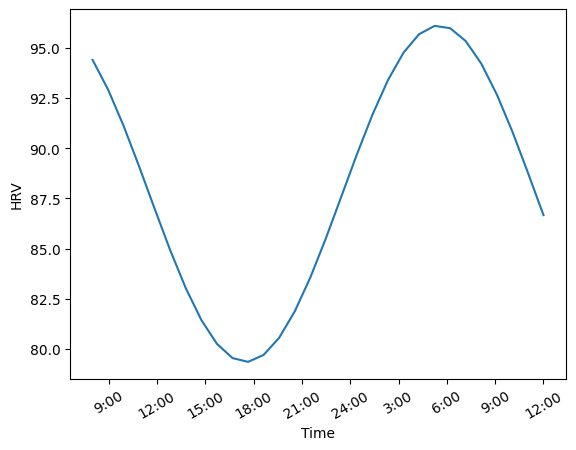

In [24]:
S_ = np.array([23., 1.80, 85., 1., 7., 20.]).reshape(-1, 1)

T_ = np.linspace(8, 36, 30)
X_ = np.asarray([np.sin(RAD_HOUR * T_), np.cos(RAD_HOUR * T_), np.ones(30, )]).T

_, ax = plt.subplots()

ticks = [[9, '9:00'], [12, '12:00'], [15, '15:00'], [18, '18:00'], [21, '21:00'], [24, '24:00'], [27, '3:00'], [30, '6:00'], [33, '9:00'], [36, '12:00']]
ax.set_xticks([x[0] for x in ticks])
ax.set_xticklabels([x[1] for x in ticks], rotation=30)
ax.set_ylabel("HRV")
ax.set_xlabel("Time")

ax.plot(T_, model.predict([X_], [S_])[0])

# Model Performance

The following evaluation methods are used to both assess performance of our model and address various claims made by the authors of the original PhysioMTL paper.  

## Evaluation Methods

In [25]:
def evaluate_all_percentages(X, S, Y, percentages, compare_alpha=0.9, physio_alpha=0.1, iterations=20, cost_func=COST_FUNC):
    for p in percentages:
        start_evaluation_time = time.perf_counter()
        evaluate_all(X, S, Y, p, compare_alpha, physio_alpha, iterations, cost_func)
        end_evaluation_time = time.perf_counter() - start_evaluation_time
        print('    Evaluation:')
        print(f'         iterations: {iterations}')
        print(f'         elapsed time: {end_evaluation_time} seconds')
        print('')

def evaluate_all(X, S, Y, percentage, compare_alpha, physio_alpha, iterations, cost_func):
    mse_physio = []
    mse_glasso = []
    mse_mlasso = []
    mse_dirty = []
    mse_mtw = []
    mse_remtw = []
    
    for _ in range(iterations):
        cutoff = int(percentage * len(S))
        idx = list(range(0, len(S)))
        random.shuffle(idx)
        train_index, test_index = idx[:cutoff], idx[cutoff:]
        X_train = [X[i] for i in train_index]
        S_train = [S[i] for i in train_index]
        Y_train = [Y[i] for i in train_index]
        X_test = [X[i] for i in test_index]
        S_test = [S[i] for i in test_index]
        Y_test = [Y[i] for i in test_index]
        
        if physio_alpha:
            model = PhysioMTL(cost_func, alpha=physio_alpha, verbose=False)
            model.fit(X_train, S_train, Y_train)
            preds = model.predict(X_test, S_test)
            mse_physio.append(get_rmse(preds, Y_test))

        x = np.zeros((len(X_train), 100, 3 + 6))
        y = np.zeros((len(X_train), 100))
        for i, s in enumerate(S_train):
            idx = list(range(0, X_train[i].shape[0]))
            random.shuffle(idx)
            x[i:i+1, :, 0:3] = X_train[i][idx[:100]]
            y[i:i+1, :] = Y_train[i][idx[:100]].reshape((1, -1))
            x[i:i+1, :, 3:] = s.reshape((1, -1))

        if compare_alpha:
            grouplasso_mse = get_mse(GroupLasso(alpha=compare_alpha), x, y, S_train, X_test, S_test, Y_test, cost_func)
            mllasso_mse = get_mse(MultiLevelLasso(alpha=compare_alpha), x, y, S_train, X_test, S_test, Y_test, cost_func)
            dirty_mse = get_mse(DirtyModel(alpha=compare_alpha), x, y, S_train, X_test, S_test, Y_test, cost_func)
            mtw_mse = get_mse(MTW(alpha=compare_alpha), x, y, S_train, X_test, S_test, Y_test, cost_func)
            remtw_mse = get_mse(ReMTW(alpha=compare_alpha), x, y, S_train, X_test, S_test, Y_test, cost_func)

            mse_glasso.append(grouplasso_mse)
            mse_mlasso.append(mllasso_mse)
            mse_dirty.append(dirty_mse)
            mse_mtw.append(mtw_mse)
            mse_remtw.append(remtw_mse)

    print(f'{percentage*100}% (alpha {compare_alpha} vs {physio_alpha})')
    if compare_alpha:
        print(f'    Group Lasso:  {np.mean(mse_glasso)} ± {np.std(mse_glasso)}')
        print(f'    MLevel Lasso: {np.mean(mse_mlasso)} ± {np.std(mse_mlasso)}')
        print(f'    Dirty Model:  {np.mean(mse_dirty)} ± {np.std(mse_dirty)}')
        print(f'    MT Was:       {np.mean(mse_mtw)} ± {np.std(mse_mtw)}')
        print(f'    MT Was Rewgt: {np.mean(mse_remtw)} ± {np.std(mse_remtw)}')
    if physio_alpha:
        print(f'    PhysioMTL:    {np.mean(mse_physio)} ± {np.std(mse_physio)}')

def get_rmse(a, b):
    return sum([np.sqrt(np.mean(np.square(a[i] - b[i]))) for i in range(len(a))]) / len(a)

def get_mse(model, X_train, Y_train, S_train, X_test, S_test, Y_test, cost_func):
    model.fit(X_train, Y_train)
    y = []
    for i, s_test in enumerate(S_test):
        idx = []
        for _, top_cost in sorted((cost_func(s, s_test), s) for s in S_train)[:1]:
            for j, s_train in enumerate(S_train):
                if np.max(s_train - top_cost) < 1e-6:
                    idx.append(j)
                    break

        X = np.zeros((len(X_test[i]), 9))
        X[:, 0:3] = X_test[i]
        X[:, 3:] = s_test.reshape((1, -1))
        y.append(X @ model.coef_[:, idx] + np.median(Y_train))

    return get_rmse(y, Y_test)

## Original Evaluation

Train the MMASH dataset using the author utilized alpha and Physio alpha values, among a variety of training ratios, using our PhysioMTL model as well as 5 other baseline models. Training across all models is done over 20 iterations.

In [26]:
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8])

20.0% (alpha 0.9 vs 0.1)
    Group Lasso:  31.181787151330877 ± 1.2379195536234968
    MLevel Lasso: 31.32605766292886 ± 1.2585241118499315
    Dirty Model:  31.1815970592235 ± 1.2374502511498449
    MT Was:       30.75505111586974 ± 1.2098855856558974
    MT Was Rewgt: 30.777092728664638 ± 1.2100879838350296
    PhysioMTL:    30.198233242256947 ± 0.6232002630322991
    Evaluation:
         iterations: 20
         elapsed time: 23.910707900000034 seconds

40.0% (alpha 0.9 vs 0.1)
    Group Lasso:  30.851938533816536 ± 1.264617729966991
    MLevel Lasso: 30.96519221733364 ± 1.2941518729483141
    Dirty Model:  30.8520375937295 ± 1.2645470896655417
    MT Was:       30.388942952621175 ± 1.1548760025892248
    MT Was Rewgt: 30.407800242448655 ± 1.1570345183795165
    PhysioMTL:    29.90187298481637 ± 0.9100191564787847
    Evaluation:
         iterations: 20
         elapsed time: 77.80602360000012 seconds

60.0% (alpha 0.9 vs 0.1)
    Group Lasso:  31.994826627433174 ± 2.053280642614477


#Experiment & Ablation Evaluations

In each of the following sections, we attempt to recreate various claims made by authors of the original paper. 

## Experiment 1: Validate Optimal Alpha

When the original authors trained the 5 baseline models for evaluation against PhysioMTL, they used a fixed alpha=0.9 (learning rate) for those models and alpha=0.1 for PhysioMTL. They stated that 0.9 was the optimal value for those other models. 

The code within this section addresses this claim by evaluating all 5 models as well as PhysioMTL across 20 iterations, each with 20%, 40%, 60%, and 80% of the MMASH data, with 10 different alpha values (0.1 to 1.0). In another words, we evaluate all 5 models across 1,000 iterations using increasing amounts of sample data and learning rates.

### For Baseline Comparison Models

Perform experimental ablation for 5 baseline models (Group lasso, multi-level lasso, dirty model, multi-task wasserstein, and reweighted multi-taks wasserstein learning models). Note that alpha 0.9 is not evaluated here, as it was done so in the Original Evaluation section above.

In [27]:
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=0.1, physio_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=0.2, physio_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=0.3, physio_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=0.4, physio_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=0.5, physio_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=0.6, physio_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=0.7, physio_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=0.8, physio_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], compare_alpha=1.0, physio_alpha=None)

20.0% (alpha 0.1 vs None)
    Group Lasso:  31.28487287267825 ± 1.6335678420975202
    MLevel Lasso: 31.30944231287978 ± 1.642366159903343
    Dirty Model:  31.28487287267825 ± 1.6335678420975202
    MT Was:       31.130801158283155 ± 1.603791229499928
    MT Was Rewgt: 31.174978323113443 ± 1.609461415948102
    Evaluation:
         iterations: 20
         elapsed time: 3.044840900000054 seconds

40.0% (alpha 0.1 vs None)
    Group Lasso:  31.49606199431372 ± 1.3106085762106994
    MLevel Lasso: 31.515236773345613 ± 1.3117208093848576
    Dirty Model:  31.49606199431372 ± 1.3106085762106994
    MT Was:       31.315798492708716 ± 1.319266821828325
    MT Was Rewgt: 31.361814181041076 ± 1.315553122299114
    Evaluation:
         iterations: 20
         elapsed time: 4.955652999999984 seconds

60.0% (alpha 0.1 vs None)
    Group Lasso:  30.983486133159175 ± 1.8321581232717377
    MLevel Lasso: 31.00069853042249 ± 1.8272404371654534
    Dirty Model:  30.983486133159175 ± 1.8321581232717377

### For PhysioMTL model


In [28]:
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.1, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.2, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.3, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.4, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.5, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.6, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.7, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.8, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=0.9, compare_alpha=None)
evaluate_all_percentages(mmash.X, mmash.S, mmash.Y, percentages=[0.2, 0.4, 0.6, 0.8], physio_alpha=1.0, compare_alpha=None)

20.0% (alpha None vs 0.1)
    PhysioMTL:    30.582562998205184 ± 0.9673387388626216
    Evaluation:
         iterations: 20
         elapsed time: 17.794998600000326 seconds

40.0% (alpha None vs 0.1)
    PhysioMTL:    30.33471316240708 ± 1.2245793625478223
    Evaluation:
         iterations: 20
         elapsed time: 67.29921769999964 seconds

60.0% (alpha None vs 0.1)
    PhysioMTL:    29.898943245342014 ± 1.5765313747537804
    Evaluation:
         iterations: 20
         elapsed time: 150.9475453999994 seconds

80.0% (alpha None vs 0.1)
    PhysioMTL:    29.818089076398927 ± 2.4676534187081405
    Evaluation:
         iterations: 20
         elapsed time: 264.2320451000005 seconds

20.0% (alpha None vs 0.2)
    PhysioMTL:    30.766755212754255 ± 1.188797184381119
    Evaluation:
         iterations: 20
         elapsed time: 18.52300869999999 seconds

40.0% (alpha None vs 0.2)
    PhysioMTL:    29.63852723074249 ± 1.0074310745680795
    Evaluation:
         iterations: 20
        

c:\Users\zayaa\workspaces\physioMTL\venv\lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\zayaa\AppData\Local\Temp\ipykernel_9368\2396204943.py:68: RuntimeWarning: invalid value encountered in scalar subtract
  if np.abs(norm_last - norm) < W_GRADIENT_THRESHOLD:
C:\Users\zayaa\AppData\Local\Temp\ipykernel_9368\2396204943.py:56: RuntimeWarning: invalid value encountered in scalar subtract
  if np.abs(norm_last - norm) < T_GRADIENT_THRESHOLD:
C:\Users\zayaa\AppData\Local\Temp\ipykernel_9368\2396204943.py:55: RuntimeWarning: overflow encountered in square
  norm = np.sum(np.square(grad))
C:\Users\zayaa\AppData\Local\Temp\ipykernel_9368\2396204943.py:67: RuntimeWarning: overflow encountered in square
  norm = np.sum(np.square(grad))
C:\Users\zayaa\AppData\Local\Temp\ipykernel_9368\3043795962.py:70: RuntimeWarning: overflow encountered in square
  return sum([np.sqrt(np.mean(np

80.0% (alpha None vs 0.9)
    PhysioMTL:    nan ± nan
    Evaluation:
         iterations: 20
         elapsed time: 290.4660322 seconds

20.0% (alpha None vs 1.0)
    PhysioMTL:    30.44230403991377 ± 0.8617808004749874
    Evaluation:
         iterations: 20
         elapsed time: 20.955675900000642 seconds

40.0% (alpha None vs 1.0)
    PhysioMTL:    30.061485002144515 ± 1.1469872745222658
    Evaluation:
         iterations: 20
         elapsed time: 75.38036250000005 seconds

60.0% (alpha None vs 1.0)
    PhysioMTL:    30.11958729041361 ± 1.537152065105629
    Evaluation:
         iterations: 20
         elapsed time: 164.6548176999986 seconds

80.0% (alpha None vs 1.0)
    PhysioMTL:    nan ± nan
    Evaluation:
         iterations: 20
         elapsed time: 567.8670009000016 seconds



## Experiment 2: Remove Denoising (Z-Score Max)

The original authors omitted HRV data more than 2.5 standard deviations from the mean, as part of denoising. Within this section, we assess this decision by training all models with 20%, 40%, 60%, and 80% of MMASH without this z-score denoising, to evaluate whether PhysioMTL still performs better.

In [29]:
tasks = [i for i in TASKS if i not in OMIT_TASKS]
mmash_no_zmax = MMASH(tasks, max_zscore=None)
evaluate_all_percentages(mmash_no_zmax.X, mmash_no_zmax.S, mmash_no_zmax.Y, percentages=[0.2, 0.4, 0.6, 0.8])

Task 1: X_i shape: (232, 3), Y_i shape: (232, 1), S_vector shape: (6,)
1: preprocessed task, y-mean = 88.26816519823224, elapsed time: 26.845441199999186 seconds
Task 2: X_i shape: (210, 3), Y_i shape: (210, 1), S_vector shape: (6,)
2: preprocessed task, y-mean = 106.69894156700501, elapsed time: 19.663620500001343 seconds
Task 3: X_i shape: (211, 3), Y_i shape: (211, 1), S_vector shape: (6,)
3: preprocessed task, y-mean = 80.96268204844812, elapsed time: 24.564099700000952 seconds
Task 5: X_i shape: (244, 3), Y_i shape: (244, 1), S_vector shape: (6,)
5: preprocessed task, y-mean = 92.00805532648388, elapsed time: 22.717559900000197 seconds
Task 6: X_i shape: (215, 3), Y_i shape: (215, 1), S_vector shape: (6,)
6: preprocessed task, y-mean = 88.97660286749205, elapsed time: 27.17670089999956 seconds
Task 7: X_i shape: (199, 3), Y_i shape: (199, 1), S_vector shape: (6,)
7: preprocessed task, y-mean = 88.3269091075991, elapsed time: 24.339625000000524 seconds
Task 8: X_i shape: (197, 3), 

## Experiment 3: Omit Unclean Sample Data

According to the original paper, the MMASH data set had some patients who were missing sleep and age data, so the authors coded assumed sleep and age numbers into the preprocessing. Doing this potentially risks confirming the authors’ biases that demographic data has very strong correlation to HRV, especially since MMASH is a relatively small data set. Thus, the code in this section performs an experiment in which we evaluate all models across 20%, 40%, 60%, and 80% of the MMASH data by excluding those patients, to see whether PhysioMTL still performs better.

In [30]:
tasks = [i for i in TASKS if i not in OMIT_TASKS and i not in OVERWRITES]
mmash_no_unclean = MMASH(tasks, max_zscore=2.5)
evaluate_all_percentages(mmash_no_unclean.X, mmash_no_unclean.S, mmash_no_unclean.Y, percentages=[0.2, 0.4, 0.6, 0.8])

Task 1: X_i shape: (226, 3), Y_i shape: (226, 1), S_vector shape: (6,)
1: preprocessed task, y-mean = 85.56476822678721, elapsed time: 24.67267460000221 seconds
Task 2: X_i shape: (204, 3), Y_i shape: (204, 1), S_vector shape: (6,)
2: preprocessed task, y-mean = 100.33561841324313, elapsed time: 19.335116399997787 seconds
Task 5: X_i shape: (239, 3), Y_i shape: (239, 1), S_vector shape: (6,)
5: preprocessed task, y-mean = 90.258288824083, elapsed time: 20.95925609999904 seconds
Task 6: X_i shape: (213, 3), Y_i shape: (213, 1), S_vector shape: (6,)
6: preprocessed task, y-mean = 88.1846116338921, elapsed time: 24.86375499999849 seconds
Task 7: X_i shape: (194, 3), Y_i shape: (194, 1), S_vector shape: (6,)
7: preprocessed task, y-mean = 85.14250546385614, elapsed time: 22.521369699999923 seconds
Task 8: X_i shape: (191, 3), Y_i shape: (191, 1), S_vector shape: (6,)
8: preprocessed task, y-mean = 96.14583988348869, elapsed time: 19.261285399999906 seconds
Task 9: X_i shape: (192, 3), Y_i 

# References

[1] Zhu, Jiacheng et al. (July 2022). “PhysioMTL: Personalizing Physiological Patterns using Optimal Transport Multi-Task Regression”. In: Proceedings of the Conference on Health, Inference, and Learning. Ed. by Gerardo Flores et al. Vol. 174. Proceedings of Machine Learning Research. PMLR, pp. 354–374. URL: https://proceedings.mlr.press/v174/zhu22a.html.

[2] Acharya, Rajendra U. et al. (2006). “Heart Rate Variability: A Review”. In: Medical and Biological Engineering and Computing 44.12, pp. 1031–1051.

[3] Rossi, Alessio et al. (2020). Multilevel Monitoring of Activity and Sleep in Healthy People (MMASH). version 1.0.0. URL: https://doi.org/10.13026/cerq-fc86.
